In [451]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt


In [452]:
df=pd.read_csv("/content/outlier_removed (1)")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [453]:
df.head()

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,0,flat,signature global park 4,sector 36,0.82,7586.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3.0,2.0,2,2.0,NaN,New Property,1081.0,NaN,650.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,360.333333
1,1,flat,smart world gems,sector 89,0.95,8597.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2.0,2.0,2,4.0,NaN,New Property,NaN,NaN,1103.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0,552.500000
2,2,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2.0,2.0,1,0.0,NaN,Under Construction,NaN,NaN,58141.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,29114.000000
3,3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2.0,2.0,1,17.0,NaN,New Property,NaN,1000.0,585.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0,292.500000
4,4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3.0,4.0,3+,10.0,North-West,Relatively New,1995.0,1615.0,1476.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0,665.000000


<Axes: xlabel='built_up_area', ylabel='price'>

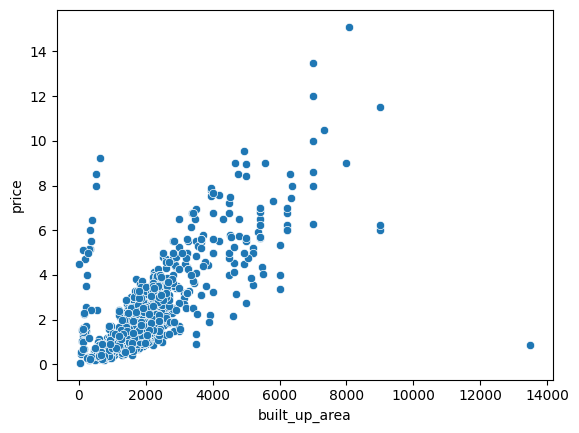

In [454]:


sns.scatterplot(data=df,x="built_up_area",y="price")

In [455]:
df.isnull().sum()

,0
Unnamed: 0,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0


<Axes: xlabel='built_up_area', ylabel='Density'>

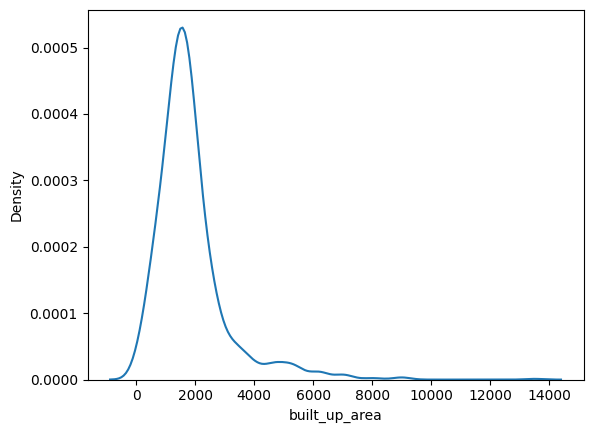

In [456]:
sns.kdeplot(df["built_up_area"])

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

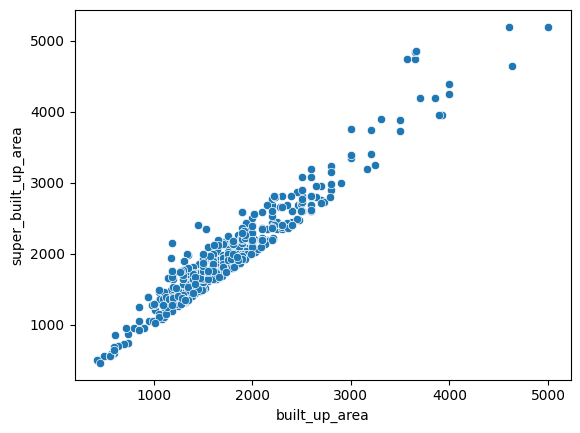

In [457]:
sns.scatterplot(data=df,x="built_up_area",y="super_built_up_area")

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

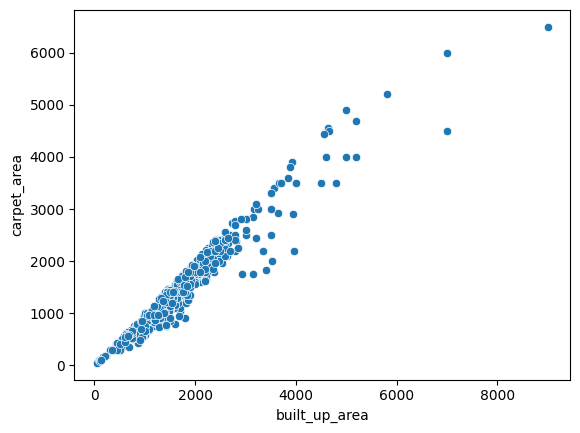

In [458]:
sns.scatterplot(data=df,x="built_up_area",y="carpet_area")

In [459]:
 df[((df["built_up_area"].isnull())&(df["super_built_up_area"].isnull())&(df["carpet_area"].isnull()))]

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio


In [460]:


all_present=  df[((df["built_up_area"].notnull())&(df["super_built_up_area"].notnull())&(df["carpet_area"].notnull()))]

In [461]:
all_present.head(3)

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
4,4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3.0,4.0,3+,10.0,North-West,Relatively New,1995.0,1615.0,1476.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0,665.0
16,17,flat,ss the leaf,sector 85,1.09,6667.0,1635.0,Super Built up area 1640(152.36 sq.m.)Built Up...,2.0,2.0,3,9.0,South-West,Relatively New,1640.0,1638.0,1635.0,0.0,0.0,1.0,0.0,0.0,0.0,174.0,817.5
17,18,flat,capital residences 360,sector 70a,1.15,11500.0,1000.0,Super Built up area 1450(134.71 sq.m.)Built Up...,2.0,2.0,3,4.0,East,New Property,1450.0,1400.0,1000.0,0.0,0.0,0.0,1.0,0.0,0.0,132.0,500.0


In [462]:
super_to_bult_up_ratio=(df["super_built_up_area"]/df["built_up_area"]).median()

In [463]:
super_to_carpet_ratio=(df["carpet_area"]/df["super_built_up_area"]).median()

In [464]:
print(super_to_carpet_ratio,super_to_bult_up_ratio)

0.7703418391911411 1.1116823529411763


In [465]:
ba_absent= df[((df["built_up_area"].isnull())&(df["super_built_up_area"].notnull())&(df["carpet_area"].notnull()))]

In [466]:
# ba_absent

In [467]:
ba_absent["built_up_area"].fillna(round(((ba_absent["super_built_up_area"]/super_to_bult_up_ratio)+(ba_absent["carpet_area"]/super_to_carpet_ratio))/2),inplace=True)

/tmp/ipykernel_8771/3736862678.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ba_absent["built_up_area"].fillna(round(((ba_absent["super_built_up_area"]/super_to_bult_up_ratio)+(ba_absent["carpet_area"]/super_to_carpet_ratio))/2),inplace=True)
/tmp/ipykernel_8771/3736862678.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ba_absent["bu

In [468]:
df.update(ba_absent)

In [469]:
df["built_up_area"].isnull().sum()

np.int64(1588)

In [470]:
sb_present=df[((df["built_up_area"].isnull())&(df["super_built_up_area"].notnull())&(df["carpet_area"].isnull()))]

In [471]:
sb_present["built_up_area"].fillna(round(sb_present["super_built_up_area"]/super_to_bult_up_ratio),inplace=True)

/tmp/ipykernel_8771/4274924426.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_present["built_up_area"].fillna(round(sb_present["super_built_up_area"]/super_to_bult_up_ratio),inplace=True)
/tmp/ipykernel_8771/4274924426.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_present["built_up_area"].fillna(round(sb_present["super_built_u

In [472]:
df.update(sb_present)

In [473]:
ca_present=df[((df["built_up_area"].isnull())&(df["super_built_up_area"].isnull())&(df["carpet_area"].notnull()))]

In [474]:
ca_present.shape

(698, 25)

In [475]:
ca_present["built_up_area"].fillna(round(ca_present["carpet_area"]/super_to_carpet_ratio),inplace=True)
df.update(ca_present)

/tmp/ipykernel_8771/574161362.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ca_present["built_up_area"].fillna(round(ca_present["carpet_area"]/super_to_carpet_ratio),inplace=True)
/tmp/ipykernel_8771/574161362.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ca_present["built_up_area"].fillna(round(ca_present["carpet_area"]/super_to_c

In [476]:
df.isnull().sum()

,0
Unnamed: 0,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0


In [477]:
df=df[df["built_up_area"]<20000]

<Axes: xlabel='built_up_area', ylabel='price'>

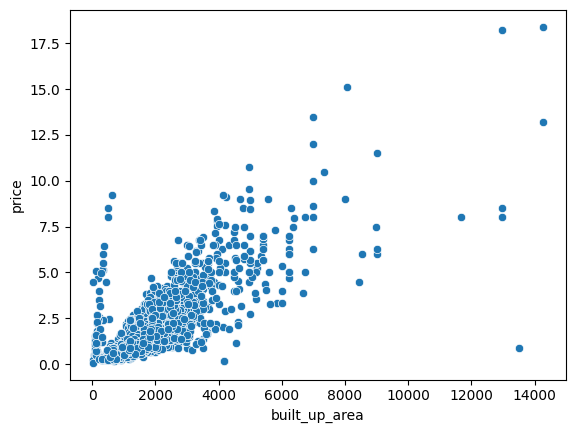

In [478]:
sns.scatterplot(data=df,x="built_up_area",y="price")

In [479]:
df.shape

(3235, 25)

In [480]:
anamoly_df=df[(df["built_up_area"]<2000 )&(df["price"]>2.5)]

In [481]:
anamoly_df["built_up_area"]=anamoly_df["area"]

/tmp/ipykernel_8771/1410172857.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anamoly_df["built_up_area"]=anamoly_df["area"]


In [482]:
df.update(anamoly_df)

In [483]:
df.shape

(3235, 25)

<Axes: xlabel='built_up_area', ylabel='price'>

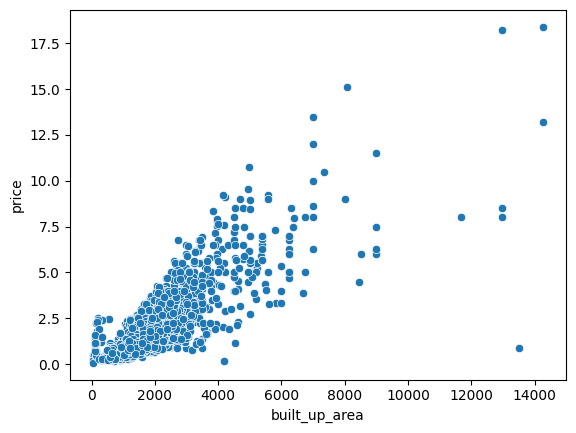

In [484]:
sns.scatterplot(data=df,x="built_up_area",y="price")

In [485]:
df.head(1)

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,0,flat,signature global park 4,sector 36,0.82,7586.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3.0,2.0,2,2.0,NaN,New Property,1081.0,908.0,650.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,360.333333


In [486]:
df.isnull().sum()

,0
Unnamed: 0,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0


In [487]:
df[df["floorNum"].isnull()]

,Unnamed: 0,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
445,521,house,independent,sector 4,0.65,11111.0,585.0,Plot area 65(54.35 sq.m.),4.0,2.0,2,NaN,NaN,Moderately Old,NaN,585.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,146.250000
688,800,house,independent,sector 7,6.50,15046.0,4320.0,Plot area 480(401.34 sq.m.),3.0,2.0,3+,NaN,NaN,Old Property,NaN,4320.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,9.0,1440.000000
1165,1348,house,independent,sector 3,1.50,10288.0,1458.0,Plot area 162(135.45 sq.m.)Built Up area: 210 ...,3.0,3.0,0,NaN,NaN,Old Property,NaN,210.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,486.000000
1766,2058,house,jacob pura,sector 12,0.35,9722.0,360.0,Built Up area: 360 (33.45 sq.m.),2.0,1.0,0,NaN,NaN,Old Property,NaN,360.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,180.000000
1949,2281,house,independent,sector 4,4.12,8889.0,4635.0,Plot area 515(430.61 sq.m.),2.0,1.0,3+,NaN,NaN,Moderately Old,NaN,4635.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2317.500000
2206,2586,house,dlf new town heights,sector 86,2.47,7719.0,3200.0,Plot area 3200(297.29 sq.m.)Built Up area: 280...,4.0,4.0,3+,NaN,West,Moderately Old,NaN,2800.0,2200.0,0.0,1.0,0.0,1.0,0.0,1.0,130.0,800.000000
2298,2693,flat,NaN,sector 78,0.60,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2.0,2.0,0,NaN,NaN,Under Construction,NaN,1625.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,812.500000
2818,3324,house,independent,sector 26,4.60,12198.0,3771.0,Plot area 419(350.34 sq.m.),4.0,4.0,3+,NaN,NaN,Old Property,NaN,3771.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,28.0,942.750000
2915,3432,flat,experion heartsong,dwarka expressway,1.08,6150.0,1756.0,Built Up area: 1758 (163.32 sq.m.),3.0,3.0,0,NaN,NaN,Under Construction,NaN,1758.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,585.333333
2953,3476,house,independent,sector 2,5.60,17284.0,3240.0,Plot area 360(301.01 sq.m.),8.0,6.0,3+,NaN,South-West,Moderately Old,NaN,3240.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,405.000000


In [488]:
df[df["property_type"]=="house"]["floorNum"].median()

2.0

In [489]:
anamoly_df['floorNum'].fillna(2,inplace=True)

/tmp/ipykernel_8771/591925588.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  anamoly_df['floorNum'].fillna(2,inplace=True)
/tmp/ipykernel_8771/591925588.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anamoly_df['floorNum'].fillna(2,inplace=True)


In [490]:
# df.drop(columns=["facing"],inplace=True)

In [491]:
df.isnull().sum()

,0
Unnamed: 0,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0


In [492]:
df.drop(index=df[df["society"].isnull()].index,inplace=True)

<Axes: xlabel='built_up_area', ylabel='Density'>

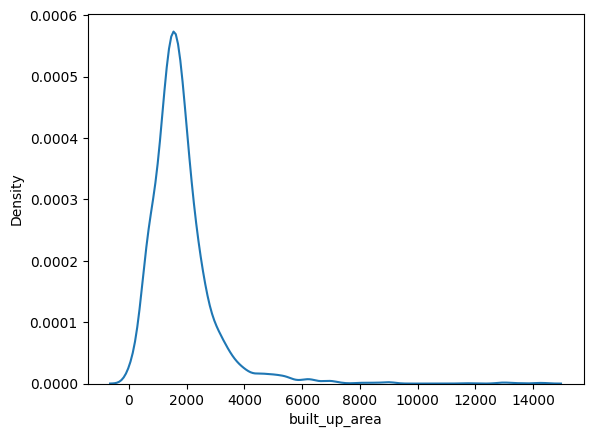

In [493]:
sns.kdeplot(df["built_up_area"])

In [494]:
df["agePossession"].value_counts()

,count
agePossession,
Relatively New,1519
New Property,548
Moderately Old,414
Undefined,282
Under Construction,266
Old Property,205


In [495]:
un=df[df["agePossession"]=="Undefined"]

In [496]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['agePossession'], df['society'])
chi2, p, dof, expected = chi2_contingency(table)

print(p)

0.0


In [497]:
new=df[(df["sector"]=="sector 4") & (df["property_type"]=="house")]["agePossession"].mode()


In [498]:
def mode_based_imputation(row):
  if row["agePossession"]=="Undefined":
    mode_value=df[(df["sector"]==row["sector"]) & (df["property_type"]==row["property_type"])]["agePossession"].mode()
    if not mode_value.empty:
      return mode_value.iloc[0]
    else:
      return np.nan
  else:
    return row["agePossession"]




In [499]:
df["agePossession"]=df.apply(mode_based_imputation,axis=1)

In [500]:
df["agePossession"].value_counts()

,count
agePossession,
Relatively New,1637
New Property,596
Moderately Old,441
Under Construction,283
Old Property,227
Undefined,50


In [501]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['agePossession'], df['sector'])
chi2, p, dof, expected = chi2_contingency(table)

print(p)

0.0


In [502]:
def mode_based_imputation2(row):
  if row["agePossession"]=="Undefined":
    mode_value=df[(df["sector"]==row["sector"])]["agePossession"].mode()
    if not mode_value.empty:
      return mode_value.iloc[0]
    else:
      return np.nan
  else:
    return row["agePossession"]


In [503]:
def mode_based_imputation3(row):
  if row["agePossession"]=="Undefined":
    mode_value=df[(df["property_type"]==row["property_type"])]["agePossession"].mode()
    if not mode_value.empty:
      return mode_value.iloc[0]
    else:
      return np.nan
  else:
    return row["agePossession"]

In [504]:
df["agePossession"]=df.apply(mode_based_imputation2,axis=1)
df["agePossession"]=df.apply(mode_based_imputation3,axis=1)

In [505]:
df["agePossession"].value_counts()

,count
agePossession,
Relatively New,1653
New Property,597
Moderately Old,446
Under Construction,283
Old Property,255


In [506]:
df.isnull().sum()


,0
Unnamed: 0,0
property_type,0
society,0
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0


In [507]:
df.columns

Index(['Unnamed: 0', 'property_type', 'society', 'sector', 'price',
       'price_per_sqft', 'area', 'areaWithType', 'bedRoom', 'bathroom',
       'balcony', 'floorNum', 'facing', 'agePossession', 'super_built_up_area',
       'built_up_area', 'carpet_area', 'study room', 'servant room',
       'store room', 'pooja room', 'others', 'furnishing_type', 'luxury_score',
       'area_room_ratio'],
      dtype='object')

In [508]:
df=df[['property_type' ,'sector', 'price','bedRoom', 'bathroom',
       'balcony', 'floorNum','agePossession',
       'built_up_area' ,'study room', 'servant room',
       'store room', 'pooja room', 'others', 'furnishing_type','luxury_score']]

In [509]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 36,0.82,3.0,2.0,2,2.0,New Property,908.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
1,flat,sector 89,0.95,2.0,2.0,2,4.0,New Property,1432.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0
3,flat,sohna road,0.32,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0
4,flat,sector 92,1.60,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0
5,flat,sector 102,0.48,2.0,2.0,1,5.0,Relatively New,630.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0


<Axes: >

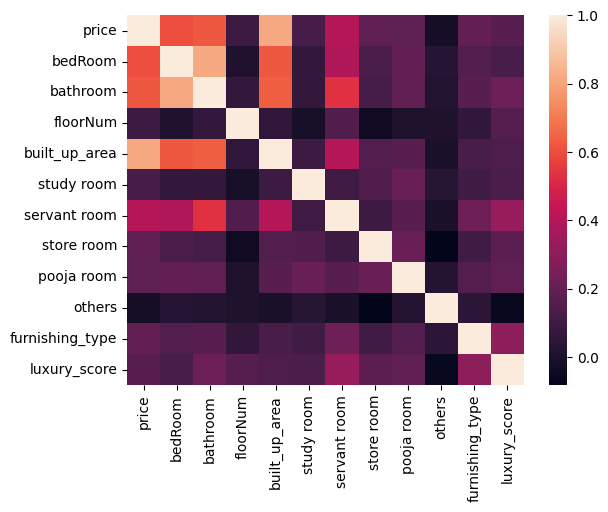

In [510]:
sns.heatmap(df.corr(numeric_only=True))

In [511]:
 df.corr(numeric_only=True)["price"].sort_values(ascending=False)

,price
price,1.000000
built_up_area,0.814202
bathroom,0.620420
bedRoom,0.599208
servant room,0.402275
furnishing_type,0.195137
store room,0.187084
pooja room,0.180636
luxury_score,0.166747
study room,0.124324
